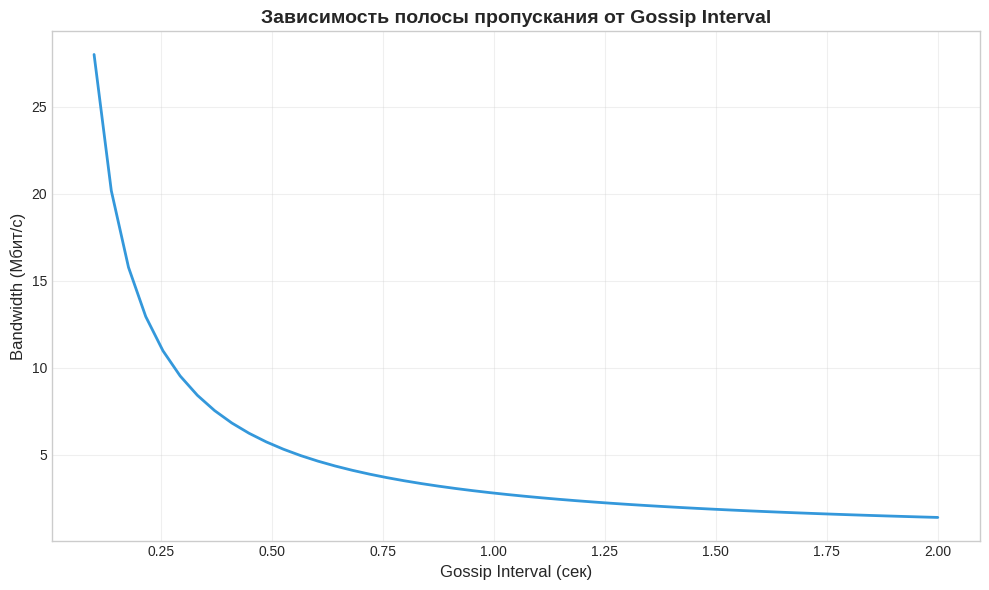

Bandwidth при Interval=0.2с, Fanout=3, N=100, Failures=5%: 14.0 Мбит/с
Запуск симуляции для варианта 17... (20-30 секунд)

РЕЗУЛЬТАТЫ СИМУЛЯЦИИ:
--------------------------------------------------------------------------------
Потери %   | Fixed время (с)    | Adaptive время (с)   | Fixed сообщ  | Adaptive сообщ 
--------------------------------------------------------------------------------
0          | 0.44               | 0.40                 | 577          | 529            
5          | 0.48               | 0.48                 | 621          | 591            
10         | 0.68               | 0.52                 | 903          | 657            
20         | 0.60               | 0.44                 | 736          | 1038           


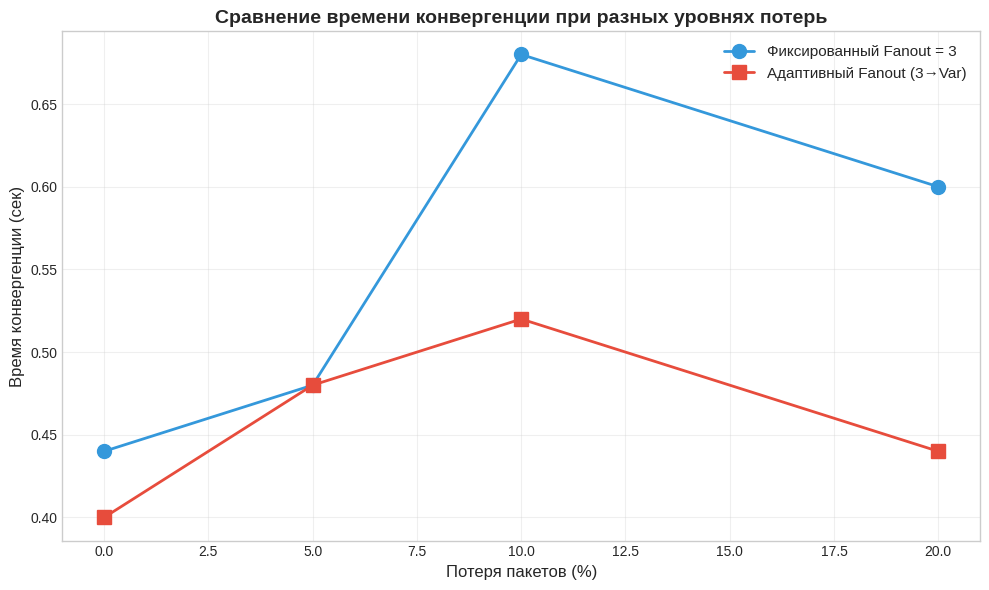

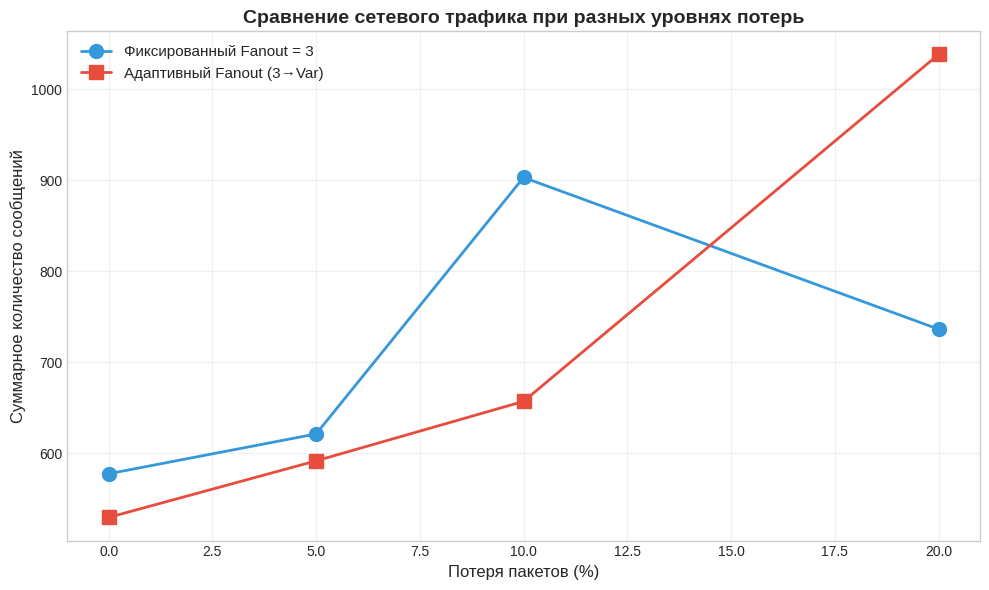

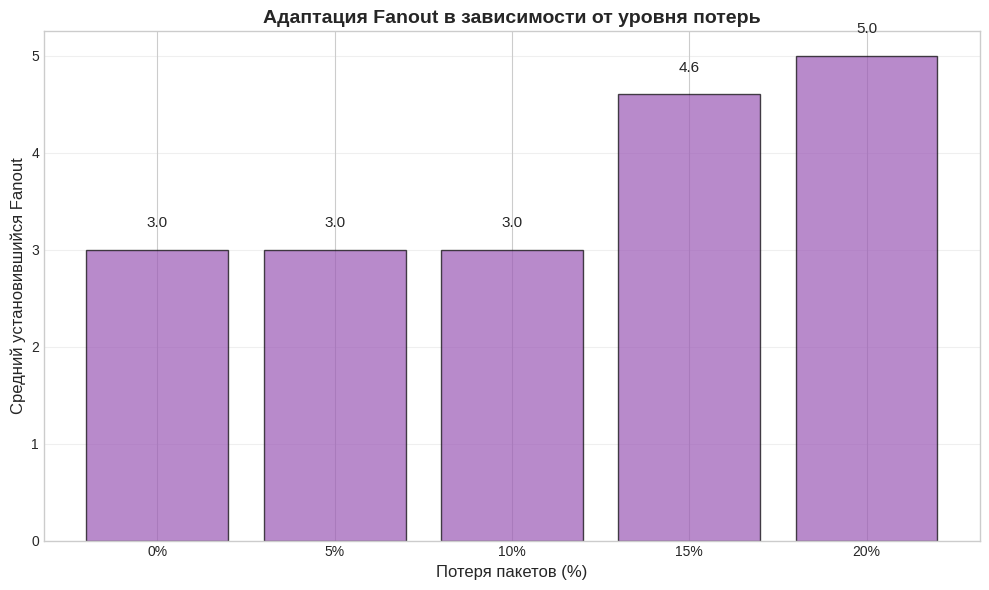

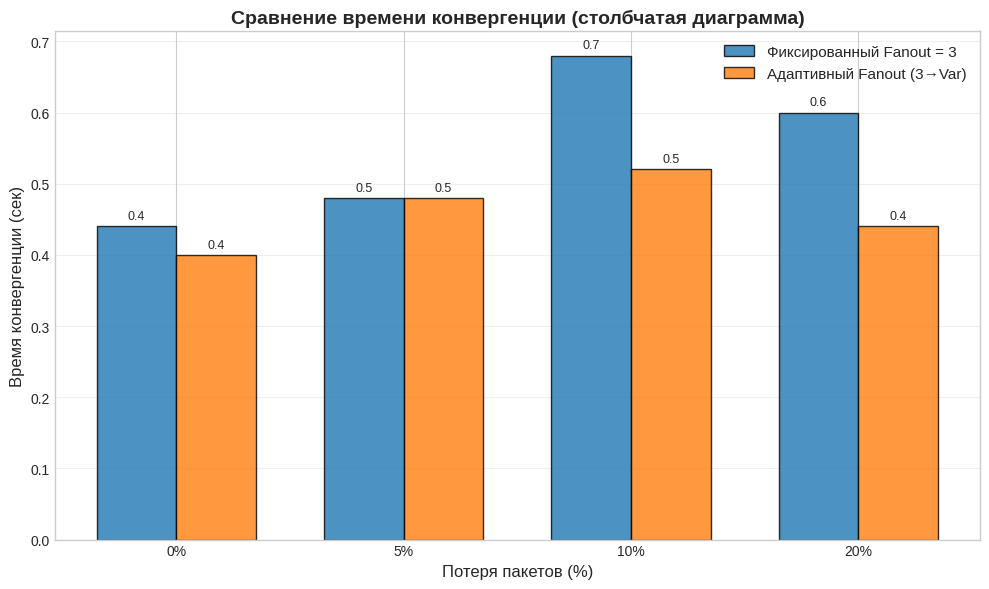

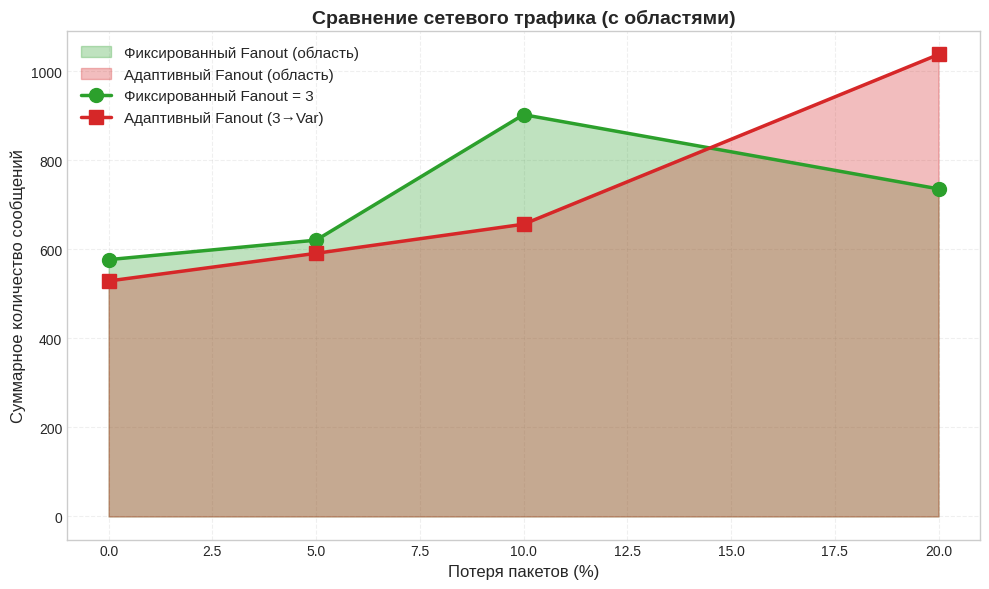

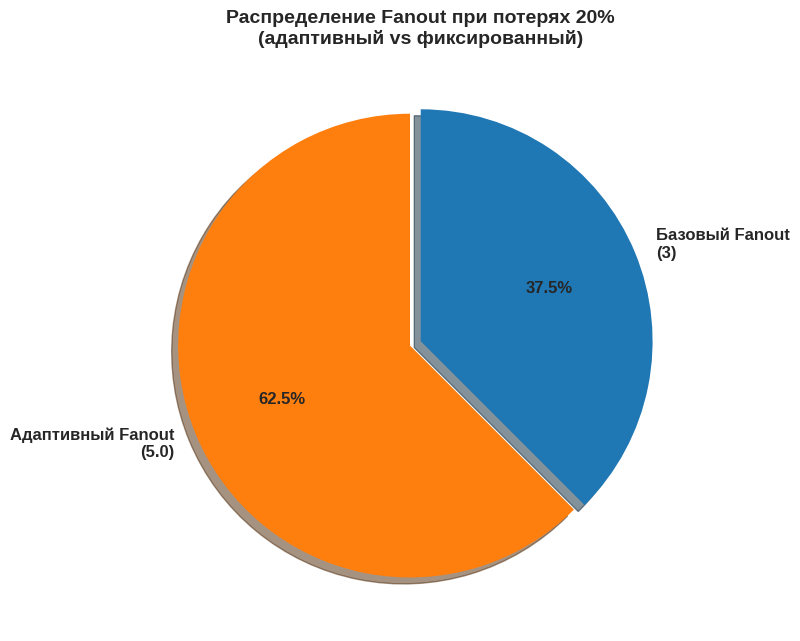

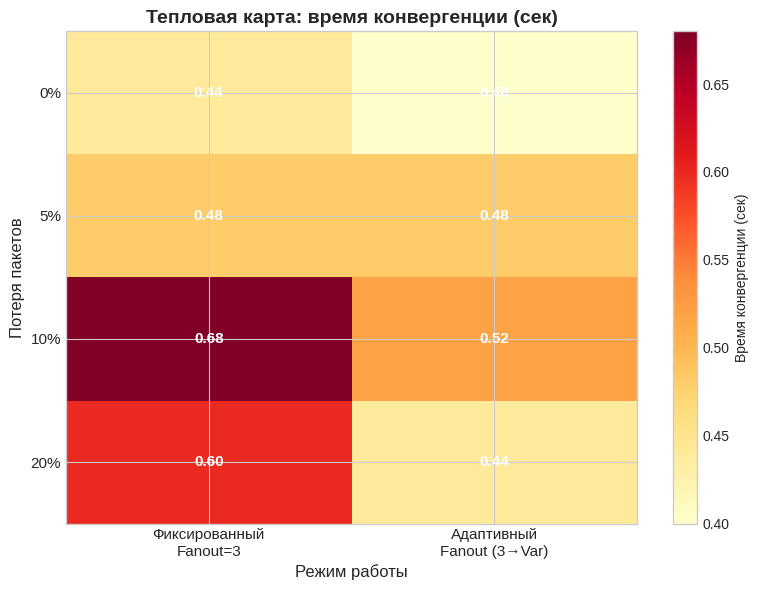

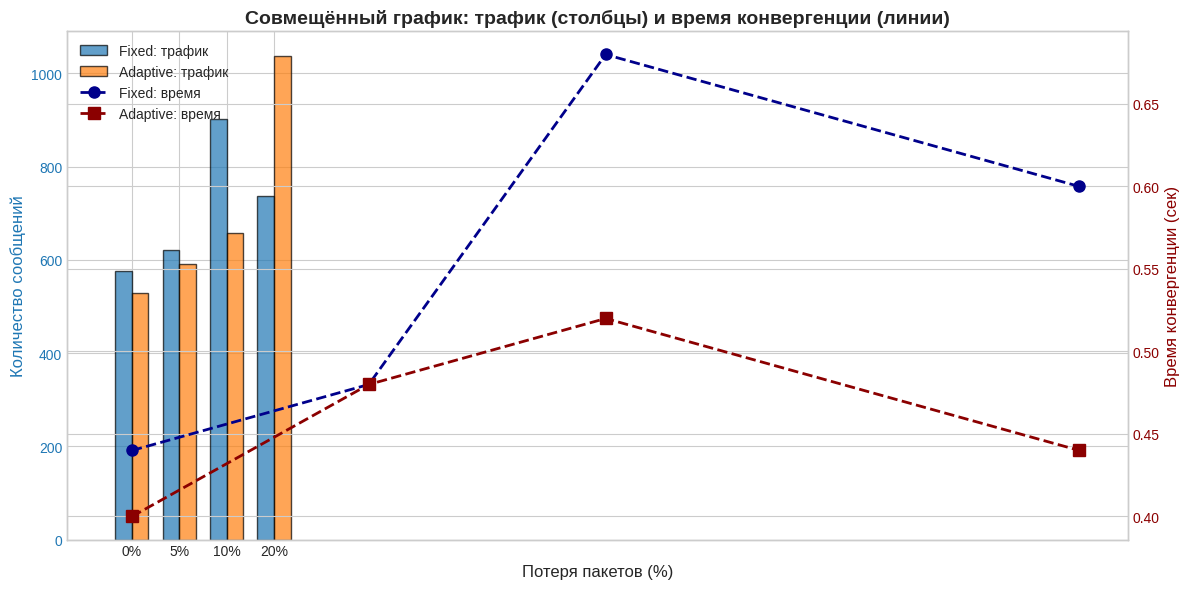


ВСЕ ГРАФИКИ ПОСТРОЕНЫ!


In [1]:
# =============================================
# ЛАБОРАТОРНАЯ РАБОТА №3_2. ВАРИАНТ 17
# Адаптивный Gossip Fanout
# =============================================

import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

random.seed(42)
np.random.seed(42)

# =============================================
# 1. РАСЧЁТ ПОЛОСЫ ПРОПУСКАНИЯ (Bandwidth)
# =============================================

def calculate_bandwidth(gossip_interval, gossip_fanout, nodes, packet_loss, node_failures):
    """
    Рассчёт полосы пропускания по формуле из методички
    """
    PACKET_SIZE = 1024  # байт
    OVERHEAD = 1.2      # 20% накладных расходов
    active_nodes = nodes * (1 - node_failures / 100)
    messages_per_second = (1 / gossip_interval) * gossip_fanout * active_nodes
    effective_messages = messages_per_second * (1 - packet_loss / 100)
    data_per_second = effective_messages * PACKET_SIZE * OVERHEAD
    bandwidth_bps = data_per_second * 8
    return bandwidth_bps

# График зависимости Bandwidth от Gossip Interval
intervals = np.linspace(0.1, 2.0, 50)
bandwidths = [calculate_bandwidth(t, 3, 100, 0, 5) / 1_000_000 for t in intervals]

plt.figure(figsize=(10, 6))
plt.plot(intervals, bandwidths, linewidth=2, color='#3498db')
plt.xlabel('Gossip Interval (сек)', fontsize=12)
plt.ylabel('Bandwidth (Мбит/с)', fontsize=12)
plt.title('Зависимость полосы пропускания от Gossip Interval', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Bandwidth при Interval=0.2с, Fanout=3, N=100, Failures=5%: {calculate_bandwidth(0.2, 3, 100, 0, 5) / 1_000_000:.1f} Мбит/с")

# =============================================
# 2. КЛАССЫ СИМУЛЯТОРОВ
# =============================================

class Node:
    def __init__(self, node_id):
        self.id = node_id
        self.knows_failure = False

class BaseSimulator:
    def __init__(self, num_nodes, interval, node_failures):
        self.nodes = [Node(i) for i in range(num_nodes)]
        self.interval = interval
        self.node_failures = node_failures
        self.failed_nodes = set()
        self.bandwidth_usage = 0

    def simulate_failure(self):
        num_failures = int(len(self.nodes) * self.node_failures / 100)
        if num_failures > 0:
            self.failed_nodes = set(random.sample(range(len(self.nodes)), num_failures))
        available_nodes = [n for n in self.nodes if n.id not in self.failed_nodes]
        if available_nodes:
            available_nodes[0].knows_failure = True

    def run_simulation(self, max_time=60):
        self.simulate_failure()
        first_knowledge_time = None
        all_knowledge_time = None
        current_time = 0

        while current_time < max_time:
            self.detect_failures()
            alive_nodes = [n for n in self.nodes if n.id not in self.failed_nodes]
            nodes_knowing = [n for n in alive_nodes if n.knows_failure]

            if first_knowledge_time is None and len(nodes_knowing) > 0:
                first_knowledge_time = current_time

            if len(nodes_knowing) == len(alive_nodes):
                all_knowledge_time = current_time
                break

            current_time += self.interval

        return first_knowledge_time or 0, all_knowledge_time or max_time, self.bandwidth_usage

class SerfSimulator(BaseSimulator):
    def __init__(self, num_nodes, gossip_interval, gossip_fanout, packet_loss, node_failures):
        super().__init__(num_nodes, gossip_interval, node_failures)
        self.gossip_fanout = gossip_fanout
        self.packet_loss = packet_loss

    def detect_failures(self):
        for node in self.nodes:
            if node.id not in self.failed_nodes and node.knows_failure:
                candidates = [n for n in range(len(self.nodes))
                             if n != node.id and n not in self.failed_nodes]
                if not candidates:
                    continue
                targets = random.sample(candidates, min(self.gossip_fanout, len(candidates)))
                for target_id in targets:
                    if random.random() > self.packet_loss / 100.0:
                        self.nodes[target_id].knows_failure = True
                    self.bandwidth_usage += 1

class HeartbeatSimulator(BaseSimulator):
    """Для сравнения в отчёте (не используется в варианте 17)"""
    def detect_failures(self):
        for node in self.nodes:
            if node.id not in self.failed_nodes:
                for other in self.nodes:
                    if other.id != node.id:
                        if other.id in self.failed_nodes:
                            node.knows_failure = True
                        self.bandwidth_usage += 1

class PingSimulator(BaseSimulator):
    """Для сравнения в отчёте (не используется в варианте 17)"""
    def detect_failures(self):
        for node in self.nodes:
            if node.id not in self.failed_nodes:
                target_id = random.choice([n for n in range(len(self.nodes)) if n != node.id])
                if target_id in self.failed_nodes:
                    node.knows_failure = True
                self.bandwidth_usage += 1

# =============================================
# 3. АДАПТИВНЫЙ СИМУЛЯТОР (ВАРИАНТ 17)
# =============================================

class AdaptiveSerfSimulator(SerfSimulator):
    def __init__(self, num_nodes, gossip_interval, base_fanout, packet_loss, node_failures,
                 loss_window=10, loss_threshold=0.3, max_fanout=10):
        super().__init__(num_nodes, gossip_interval, base_fanout, packet_loss, node_failures)
        self.base_fanout = base_fanout
        self.current_fanout = base_fanout
        self.max_fanout = max_fanout
        self.loss_threshold = loss_threshold
        self.loss_window = loss_window
        self.send_success_history = []

    def _update_fanout(self):
        if len(self.send_success_history) < self.loss_window:
            return
        loss_rate = 1.0 - sum(self.send_success_history) / len(self.send_success_history)
        if loss_rate > self.loss_threshold:
            self.current_fanout = min(self.max_fanout, self.current_fanout + 1)
        elif loss_rate < self.loss_threshold / 2 and self.current_fanout > self.base_fanout:
            self.current_fanout = max(self.base_fanout, self.current_fanout - 1)

    def detect_failures(self):
        for node in self.nodes:
            if node.id not in self.failed_nodes and node.knows_failure:
                candidates = [n for n in range(len(self.nodes))
                             if n != node.id and n not in self.failed_nodes]
                if not candidates:
                    continue

                self._update_fanout()
                fanout_now = self.current_fanout
                targets = random.sample(candidates, min(fanout_now, len(candidates)))

                for target_id in targets:
                    success = random.random() > self.packet_loss / 100.0
                    self.send_success_history.append(success)
                    if len(self.send_success_history) > self.loss_window:
                        self.send_success_history.pop(0)

                    if success:
                        self.nodes[target_id].knows_failure = True
                    self.bandwidth_usage += 1

# =============================================
# 4. ФУНКЦИЯ СРАВНЕНИЯ (FIXED vs ADAPTIVE)
# =============================================

def compare_fixed_vs_adaptive():
    packet_loss_levels = [0, 5, 10, 20]
    nodes = 100
    interval = 0.2
    base_fanout = 3
    failures = 5
    trials = 5

    results = {
        'fixed': {'times': [], 'msgs': []},
        'adaptive': {'times': [], 'msgs': []}
    }

    for pl in packet_loss_levels:
        fixed_times = []
        fixed_msgs = []
        adapt_times = []
        adapt_msgs = []

        for _ in range(trials):
            sim_fixed = SerfSimulator(nodes, interval, base_fanout, pl, failures)
            _, conv_fixed, msgs_fixed = sim_fixed.run_simulation()
            fixed_times.append(conv_fixed)
            fixed_msgs.append(msgs_fixed)

            sim_adapt = AdaptiveSerfSimulator(nodes, interval, base_fanout, pl, failures)
            _, conv_adapt, msgs_adapt = sim_adapt.run_simulation()
            adapt_times.append(conv_adapt)
            adapt_msgs.append(msgs_adapt)

        results['fixed']['times'].append(np.mean(fixed_times))
        results['fixed']['msgs'].append(np.mean(fixed_msgs))
        results['adaptive']['times'].append(np.mean(adapt_times))
        results['adaptive']['msgs'].append(np.mean(adapt_msgs))

    return packet_loss_levels, results

# =============================================
# 5. ЗАПУСК СИМУЛЯЦИИ
# =============================================

print("="*70)
print("Запуск симуляции для варианта 17... (20-30 секунд)")
print("="*70)

packet_loss_levels, comp = compare_fixed_vs_adaptive()

print("\nРЕЗУЛЬТАТЫ СИМУЛЯЦИИ:")
print("-" * 80)
print(f"{'Потери %':<10} | {'Fixed время (с)':<18} | {'Adaptive время (с)':<20} | {'Fixed сообщ':<12} | {'Adaptive сообщ':<15}")
print("-" * 80)
for i, pl in enumerate(packet_loss_levels):
    print(f"{pl:<10} | {comp['fixed']['times'][i]:<18.2f} | {comp['adaptive']['times'][i]:<20.2f} | {comp['fixed']['msgs'][i]:<12.0f} | {comp['adaptive']['msgs'][i]:<15.0f}")

# =============================================
# 6. ГРАФИК 1: Время конвергенции (линейный)
# =============================================

plt.figure(figsize=(10, 6))
plt.plot(packet_loss_levels, comp['fixed']['times'], 'o-', linewidth=2, markersize=10,
         label='Фиксированный Fanout = 3', color='#3498db')
plt.plot(packet_loss_levels, comp['adaptive']['times'], 's-', linewidth=2, markersize=10,
         label='Адаптивный Fanout (3→Var)', color='#e74c3c')
plt.xlabel('Потеря пакетов (%)', fontsize=12)
plt.ylabel('Время конвергенции (сек)', fontsize=12)
plt.title('Сравнение времени конвергенции при разных уровнях потерь', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================
# 7. ГРАФИК 2: Сетевой трафик (линейный)
# =============================================

plt.figure(figsize=(10, 6))
plt.plot(packet_loss_levels, comp['fixed']['msgs'], 'o-', linewidth=2, markersize=10,
         label='Фиксированный Fanout = 3', color='#3498db')
plt.plot(packet_loss_levels, comp['adaptive']['msgs'], 's-', linewidth=2, markersize=10,
         label='Адаптивный Fanout (3→Var)', color='#e74c3c')
plt.xlabel('Потеря пакетов (%)', fontsize=12)
plt.ylabel('Суммарное количество сообщений', fontsize=12)
plt.title('Сравнение сетевого трафика при разных уровнях потерь', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================
# 8. ГРАФИК 3: Средний Fanout
# =============================================

def measure_avg_fanout(packet_loss, trials=5):
    fanouts = []
    for _ in range(trials):
        sim = AdaptiveSerfSimulator(100, 0.2, 3, packet_loss, 5)
        sim.simulate_failure()
        for _ in range(30):
            sim.detect_failures()
        fanouts.append(sim.current_fanout)
    return np.mean(fanouts)

losses = [0, 5, 10, 15, 20]
avg_fanouts = [measure_avg_fanout(pl) for pl in losses]

plt.figure(figsize=(10, 6))
bars = plt.bar([f"{l}%" for l in losses], avg_fanouts, color='#9b59b6', edgecolor='black', alpha=0.7)
plt.xlabel('Потеря пакетов (%)', fontsize=12)
plt.ylabel('Средний установившийся Fanout', fontsize=12)
plt.title('Адаптация Fanout в зависимости от уровня потерь', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, avg_fanouts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

# =============================================
# 9. ГРАФИК 4: Столбчатая диаграмма для времени
# =============================================

x = np.arange(len(packet_loss_levels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, comp['fixed']['times'], width,
               label='Фиксированный Fanout = 3', color='#1f77b4', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, comp['adaptive']['times'], width,
               label='Адаптивный Fanout (3→Var)', color='#ff7f0e', edgecolor='black', alpha=0.8)
ax.set_xlabel('Потеря пакетов (%)', fontsize=12)
ax.set_ylabel('Время конвергенции (сек)', fontsize=12)
ax.set_title('Сравнение времени конвергенции (столбчатая диаграмма)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{pl}%' for pl in packet_loss_levels])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# =============================================
# 10. ГРАФИК 5: Области для трафика
# =============================================

plt.figure(figsize=(10, 6))
plt.fill_between(packet_loss_levels, comp['fixed']['msgs'], alpha=0.3, color='#2ca02c',
                 label='Фиксированный Fanout (область)')
plt.fill_between(packet_loss_levels, comp['adaptive']['msgs'], alpha=0.3, color='#d62728',
                 label='Адаптивный Fanout (область)')
plt.plot(packet_loss_levels, comp['fixed']['msgs'], 'o-', linewidth=2.5, markersize=10,
         color='#2ca02c', label='Фиксированный Fanout = 3')
plt.plot(packet_loss_levels, comp['adaptive']['msgs'], 's-', linewidth=2.5, markersize=10,
         color='#d62728', label='Адаптивный Fanout (3→Var)')
plt.xlabel('Потеря пакетов (%)', fontsize=12)
plt.ylabel('Суммарное количество сообщений', fontsize=12)
plt.title('Сравнение сетевого трафика (с областями)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# =============================================
# 11. ГРАФИК 6: Круговая диаграмма для Fanout при 20% потерь
# =============================================

idx_20 = losses.index(20)
adaptive_fanout_at_20 = avg_fanouts[idx_20]

sizes = [adaptive_fanout_at_20, 3]
labels = [f'Адаптивный Fanout\n({adaptive_fanout_at_20:.1f})', f'Базовый Fanout\n(3)']
colors_pie = ['#ff7f0e', '#1f77b4']
explode = (0.05, 0)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title(f'Распределение Fanout при потерях 20%\n(адаптивный vs фиксированный)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================
# 12. ГРАФИК 7: Тепловая карта (heatmap)
# =============================================

heatmap_data = np.array([comp['fixed']['times'], comp['adaptive']['times']]).T
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Фиксированный\nFanout=3', 'Адаптивный\nFanout (3→Var)'], fontsize=11)
ax.set_yticks(range(len(packet_loss_levels)))
ax.set_yticklabels([f'{pl}%' for pl in packet_loss_levels], fontsize=11)
ax.set_xlabel('Режим работы', fontsize=12)
ax.set_ylabel('Потеря пакетов', fontsize=12)
ax.set_title('Тепловая карта: время конвергенции (сек)', fontsize=14, fontweight='bold')
for i in range(len(packet_loss_levels)):
    for j in range(2):
        ax.text(j, i, f'{heatmap_data[i, j]:.2f}', ha="center", va="center",
                color="white", fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='Время конвергенции (сек)')
plt.tight_layout()
plt.show()

# =============================================
# 13. ГРАФИК 8: Совмещённый
# =============================================

fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(packet_loss_levels))
width = 0.35
bars1 = ax1.bar(x - width/2, comp['fixed']['msgs'], width,
                label='Fixed: трафик', color='#1f77b4', alpha=0.7, edgecolor='black')
bars2 = ax1.bar(x + width/2, comp['adaptive']['msgs'], width,
                label='Adaptive: трафик', color='#ff7f0e', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Потеря пакетов (%)', fontsize=12)
ax1.set_ylabel('Количество сообщений', color='#1f77b4', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{pl}%' for pl in packet_loss_levels])

ax2 = ax1.twinx()
ax2.plot(packet_loss_levels, comp['fixed']['times'], 'o--', linewidth=2, markersize=8,
         color='darkblue', label='Fixed: время')
ax2.plot(packet_loss_levels, comp['adaptive']['times'], 's--', linewidth=2, markersize=8,
         color='darkred', label='Adaptive: время')
ax2.set_ylabel('Время конвергенции (сек)', color='darkred', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkred')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
plt.title('Совмещённый график: трафик (столбцы) и время конвергенции (линии)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ВСЕ ГРАФИКИ ПОСТРОЕНЫ!")